In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")

a = 10
x0 = 5
N = 100000

tau_list = []

for _ in range(N):
    x = x0
    tau = 0
    while x != 0 and x != a:
        x += 1 if np.random.rand() > 0.5 else -1
        tau += 1
    tau_list.append(tau)

tau_array = np.array(tau_list)

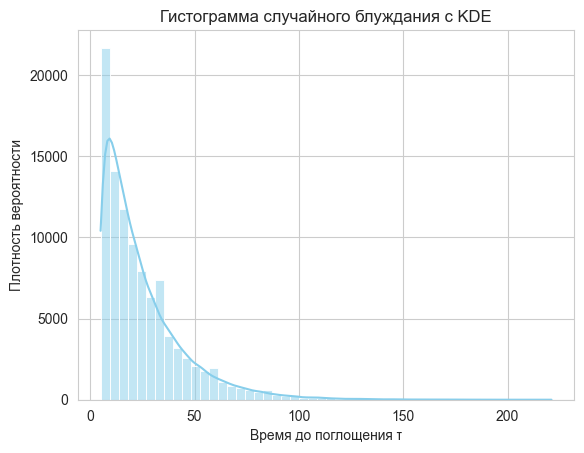

In [2]:
sns.histplot(tau_array, bins=50, kde=True, color="skyblue")
plt.xlabel("Время до поглощения τ")
plt.ylabel("Плотность вероятности")
plt.title("Гистограмма случайного блуждания с KDE")
plt.show()

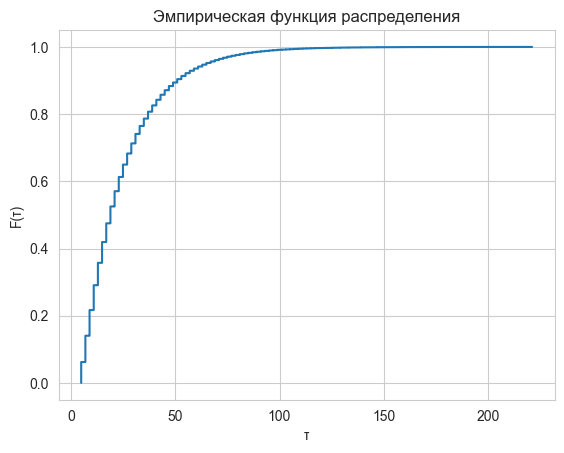

In [3]:
sorted_tau = np.sort(tau_array)
ecdf = np.arange(1, N + 1) / N
plt.step(sorted_tau, ecdf, where="post")
plt.xlabel("τ")
plt.ylabel("F(τ)")
plt.title("Эмпирическая функция распределения")
plt.show()

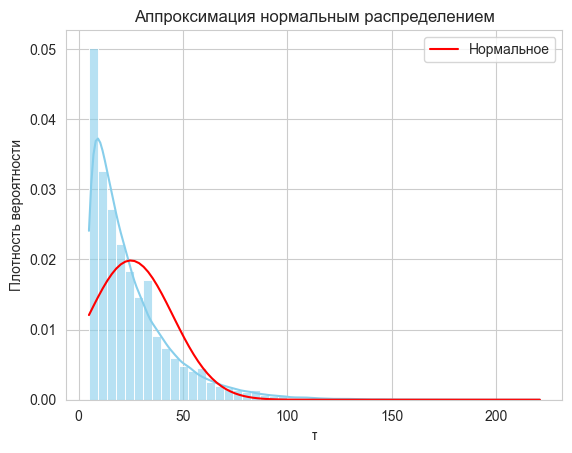

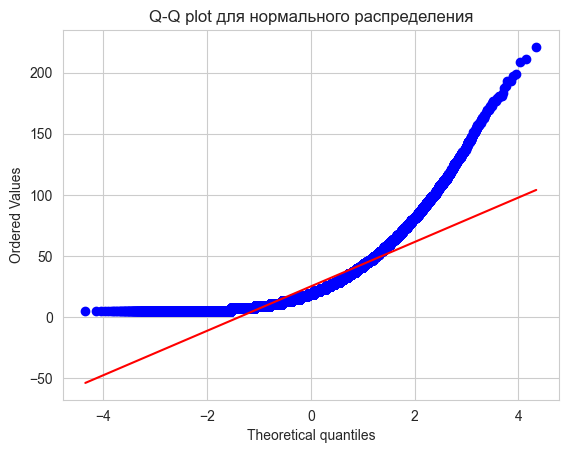

In [4]:
mu, sigma = stats.norm.fit(tau_array)
sns.histplot(tau_array, bins=50, kde=True, color="skyblue", stat="density", alpha=0.6)
x_vals = np.linspace(min(tau_array), max(tau_array), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, mu, sigma), "r", label="Нормальное")
plt.xlabel("τ")
plt.ylabel("Плотность вероятности")
plt.title("Аппроксимация нормальным распределением")
plt.legend()
plt.show()

stats.probplot(tau_array, dist="norm", plot=plt)
plt.title("Q-Q plot для нормального распределения")
plt.show()

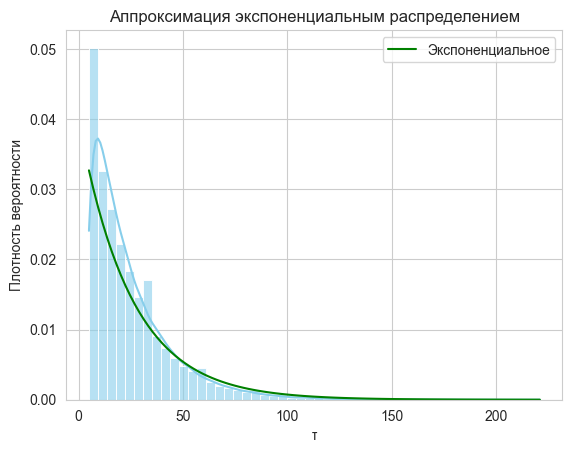

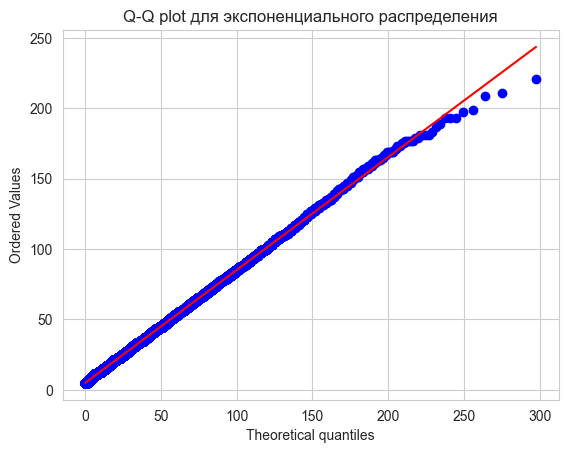

In [5]:
lambda_est = 1 / np.mean(tau_array)
sns.histplot(tau_array, bins=50, kde=True, color="skyblue", stat="density", alpha=0.6)
plt.plot(
    x_vals, stats.expon.pdf(x_vals, scale=1 / lambda_est), "g", label="Экспоненциальное"
)
plt.xlabel("τ")
plt.ylabel("Плотность вероятности")
plt.title("Аппроксимация экспоненциальным распределением")
plt.legend()
plt.show()

stats.probplot(tau_array, dist=stats.expon, sparams=(0, 1 / lambda_est), plot=plt)
plt.title("Q-Q plot для экспоненциального распределения")
plt.show()

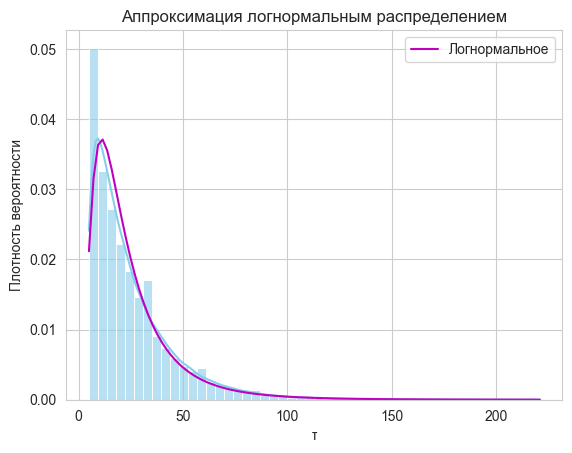

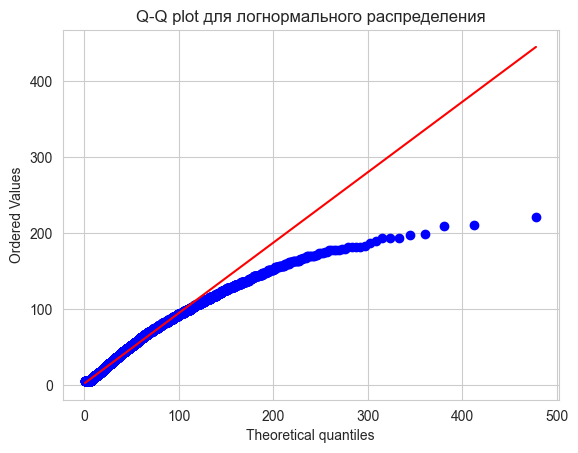

In [6]:
shape, loc, scale = stats.lognorm.fit(tau_array, floc=0)
sns.histplot(tau_array, bins=50, kde=True, color="skyblue", stat="density", alpha=0.6)
plt.plot(
    x_vals,
    stats.lognorm.pdf(x_vals, s=shape, loc=loc, scale=scale),
    "m",
    label="Логнормальное",
)
plt.xlabel("τ")
plt.ylabel("Плотность вероятности")
plt.title("Аппроксимация логнормальным распределением")
plt.legend()
plt.show()

stats.probplot(tau_array, dist=stats.lognorm, sparams=(shape, loc, scale), plot=plt)
plt.title("Q-Q plot для логнормального распределения")
plt.show()

Пусть случайная величина $\tau$ имеет экспоненциальное распределение с параметром $\lambda$:

$f(t)=\lambda e^{-\lambda t}, \quad t \ge 0$

Основные характеристики:

$\mu = \frac{1}{\lambda}$

$\sigma = \frac{1}{\lambda}$

Пусть есть выборка независимых наблюдений

$\tau_1, \tau_2, ..., \tau_n$

$\bar{\tau} = \frac{1}{n}\sum_{i=1}^{n}\tau_i$

$\mu (\bar{\tau}) = \mu \left( \frac{1}{n} \sum \limits_{i = 1}^n \tau_i \right) = \frac{1}{n} \sum \limits_{i = 1}^n \mu(\tau_i)$

$\mu (\bar{\tau}) = \frac{1}{n} \cdot n \mu = \mu$

$D (\bar{\tau}) = D \left( \frac{1}{n} \sum \limits_{i = 1}^n \tau_i \right) = \frac{1}{n^2} \sum \limits_{i = 1}^n D(\tau_i)$

$D (\bar{\tau}) = \frac{1}{n^2} \cdot n \sigma^2 = \frac{\sigma^2}{n}$

$\sigma (\bar{\tau}) = \frac{\sigma}{\sqrt{n}}$

По центральной предельной теореме (для большого $n$):

$\bar{\tau} \sim N\left(\mu, \frac{\sigma^2}{n} \right)$

Для нормального распределения:

$P(\left| \frac{\bar{\tau} - \mu}{\sigma / \sqrt{n}} \right| < \Delta) = 1 - \alpha$, где $\Delta = z_{1 - \alpha / 2}$

Доверительный интервал:

$\bar{\tau} \pm \Delta \frac{\sigma}{\sqrt{n}}$

Мы хотим, чтобы ошибка оценки среднего не превышала долю ($\delta$) от среднего:

$\left| \bar{\tau}-\mu \right| \le \delta\mu$

Половина доверительного интервала должна равняться этой величине:

$z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}} = \delta\mu$

Отсюда:

$n = \left(\frac{z_{1-\alpha/2}\sigma}{\delta\mu}\right)^2$

Для экспоненциального распределения:

$\sigma = \mu$

$n = \left(\frac{z_{1-\alpha/2}}{\delta}\right)^2$

---

Выборочная дисперсия определяется как:

$s^2 = \frac{1}{n - 1} \sum \limits_{i = 1}^n (\tau_i - \bar{\tau})^2$

Если выборка из нормального распределения, то:

$Y = \frac{(n - 1) s^2}{\sigma^2} \sim \chi_{n - 1}^2$

Для 

$Y \sim \chi_{n - 1}^2$

$\mu(Y) = n - 1$

$D(Y) = 2(n - 1)$

$s^2 = \frac{\sigma^2}{n - 1} Y$

$D(s^2) = \left( \frac{\sigma^2}{n - 1} \right)^2 \cdot D(Y) = \frac{2 \sigma^4}{n - 1}$

По центральной предельной теореме (для большого $n$):

$s^2 \sim N(\sigma^2, \frac{2 \sigma^4}{n - 1})$

Доверительный интервал:

$s^2 \pm \Delta \sigma^2 \sqrt{\frac{2}{n-1}}$

Мы хотим, чтобы ошибка оценки дисперсии не превышала долю $\delta_v$

$\left| s^2 - \sigma^2 \right| < \delta_v \sigma^2$

Половина доверительного интервала должна равняться этой величине:

$z_{1-\alpha/2} \sigma^2 \sqrt{\frac{2}{n-1}} = \delta_v \sigma^2$

$z_{1-\alpha/2} \sqrt{\frac{2}{n-1}} = \delta_v$

Отсюда:

$n - 1 = \frac{2 z_{1 - \alpha/2}^2}{\delta_v^2}$

Для больших n:

$n \approx \frac{2 z_{1 - \alpha/2}^2}{\delta_v^2}$

In [7]:
delta_mean = 0.05  # точность среднего
delta_var = 0.05  # точность дисперсии
alpha = 0.05  # уровень значимости

z = stats.norm.ppf(1 - alpha / 2)

n_mean = (z / delta_mean) ** 2
print(f"Объем выборки для оценки среднего: {int(np.ceil(n_mean))}")

n_var = 2 * z**2 / delta_var**2
print(f"Объем выборки для оценки дисперсии: {int(np.ceil(n_var))}")

Объем выборки для оценки среднего: 1537
Объем выборки для оценки дисперсии: 3074
